# Test 6: Classical-Only Retrain ⚠️ GPU RECOMMENDED

Train the model from scratch with `classical_only=True`. This removes the entire
quantum branch (~69k params). Compare against the hybrid model.

**Key question:** Does a model without any quantum components perform worse, equal, or better?

In [1]:
from setup_helpers import *
from ariel_quantum_regression.training import (
    TrainingConfig, train_model, move_prepared_data_to_device,
    evaluate_labeled_split
)
from ariel_quantum_regression.model import build_model as build_model_fn
import time

ckpt = load_checkpoint()
cfg = ckpt["config"]

HAS_GPU = torch.cuda.is_available()
print(f"GPU available: {HAS_GPU}")
if not HAS_GPU:
    print("WARNING: Full retrain is slow on CPU (~12 min/epoch). Consider GPU.")

GPU available: False


In [2]:
# Configure classical-only training (use same hyperparams as original)
assert "batch_size" in cfg, f"Missing batch_size in checkpoint config. Keys: {list(cfg.keys())}"
assert "classical_lr" in cfg, f"Missing classical_lr in checkpoint config."
assert "dropout" in cfg, f"Missing dropout in checkpoint config."

train_cfg = TrainingConfig(
    data_root=str(DATA_ROOT),
    output_dir=str(Path("./outputs/classical_only")),
    dataset_format="adc",
    seed=42,
    batch_size=cfg["batch_size"],
    max_epochs=30,
    early_stop_patience=8,
    classical_lr=cfg["classical_lr"],
    dropout=cfg["dropout"],
    classical_only=True,  # No quantum branch
    qnn_qubits=cfg["qnn_qubits"],
    qnn_depth=cfg["qnn_depth"],
)

print(f"Training classical-only model with same hyperparams...")
print(f"  lr={train_cfg.classical_lr}, dropout={train_cfg.dropout}")
print(f"  max_epochs={train_cfg.max_epochs}, patience={train_cfg.early_stop_patience}")

Training classical-only model with same hyperparams...
  lr=5e-05, dropout=0.05
  max_epochs=30, patience=8


In [3]:
# Load data
data = load_data()

# Move to GPU if available
train_device = torch.device("cuda" if HAS_GPU else "cpu")
if HAS_GPU:
    move_prepared_data_to_device(data, train_device)
    print(f"Data moved to {train_device}")

In [5]:
# Train classical-only model
start_time = time.time()
result = train_model(train_cfg, data, train_device, Path("./outputs/classical_only"))
elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"Best epoch: {result['best_epoch']}")
print(f"Best val mRMSE: {result['best_val_rmse']:.4f}")

Torch device: cpu | Quantum device: lightning.qubit | classical_only=True
Loss: mse | Quantum warmup epochs: 0 | Quantum ramp epochs: 0 | Backbone freeze epochs: 0
Epoch 1/30 | Batch 20/2072 | batch_loss=0.86840 | avg_loss=0.99008 | batch_time=0.02s
Epoch 1/30 | Batch 40/2072 | batch_loss=1.20963 | avg_loss=1.00169 | batch_time=0.02s
Epoch 1/30 | Batch 60/2072 | batch_loss=1.20426 | avg_loss=1.00058 | batch_time=0.02s
Epoch 1/30 | Batch 80/2072 | batch_loss=0.85501 | avg_loss=0.99371 | batch_time=0.02s
Epoch 1/30 | Batch 100/2072 | batch_loss=0.83809 | avg_loss=0.98541 | batch_time=0.02s
Epoch 1/30 | Batch 120/2072 | batch_loss=0.76160 | avg_loss=0.97476 | batch_time=0.02s
Epoch 1/30 | Batch 140/2072 | batch_loss=0.80622 | avg_loss=0.95657 | batch_time=0.02s
Epoch 1/30 | Batch 160/2072 | batch_loss=0.85422 | avg_loss=0.94290 | batch_time=0.02s
Epoch 1/30 | Batch 180/2072 | batch_loss=1.09008 | avg_loss=0.93256 | batch_time=0.02s
Epoch 1/30 | Batch 200/2072 | batch_loss=0.69047 | avg_lo

In [6]:
# Evaluate classical-only on holdout
classical_model = result["model"]
classical_model.eval()

# Move holdout back to correct device if needed
holdout_classical = evaluate_labeled_split(
    classical_model, data.holdout, data.target_scaler,
    batch_size=BATCH_SIZE, loss_fn=LOSS_FN,
    enable_quantum=False,
)

# Load quantum model for comparison
model_q, _, _ = build_trained_model(ckpt)
holdout_quantum = evaluate(model_q, data.holdout, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
holdout_q_off = evaluate(model_q, data.holdout, data.target_scaler, enable_quantum=False)

comparison = {
    "Hybrid: Quantum OFF": holdout_q_off,
    "Hybrid: Quantum ON (s=0.5)": holdout_quantum,
    "Classical-Only Retrain": holdout_classical,
}

print("=== Holdout Comparison ===")
display(compare_table(comparison))

=== Holdout Comparison ===


,mRMSE,mMAE,RMSE H₂O,RMSE CO₂,RMSE CO,RMSE CH₄,RMSE NH₃
Condition,,,,,,,
Hybrid: Quantum OFF,0.3024,0.1834,0.4030,0.2433,0.2324,0.2350,0.3983
Hybrid: Quantum ON (s=0.5),0.2956,0.1792,0.3909,0.2329,0.2297,0.2342,0.3901
Classical-Only Retrain,0.3616,0.2340,0.4741,0.3028,0.2820,0.2924,0.4566


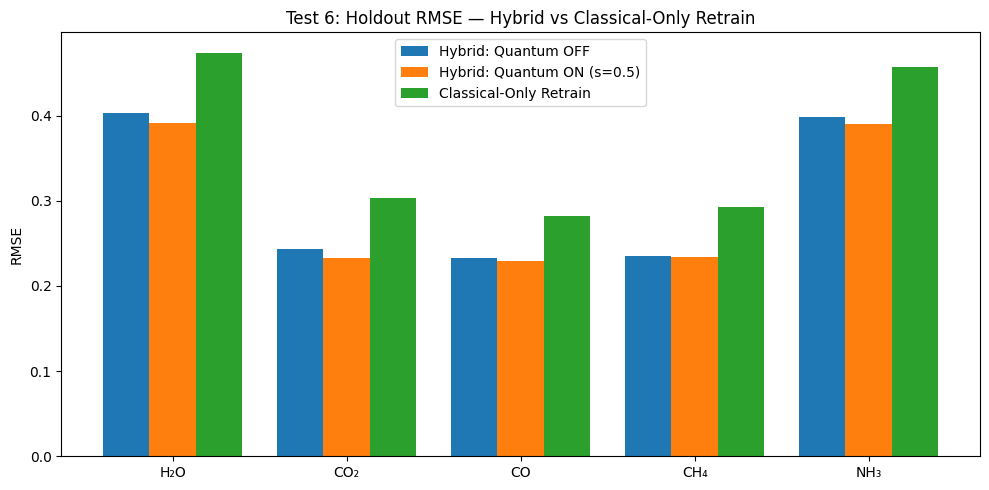

In [7]:
fig = plot_per_target(comparison, "Test 6: Holdout RMSE — Hybrid vs Classical-Only Retrain")
plt.show()

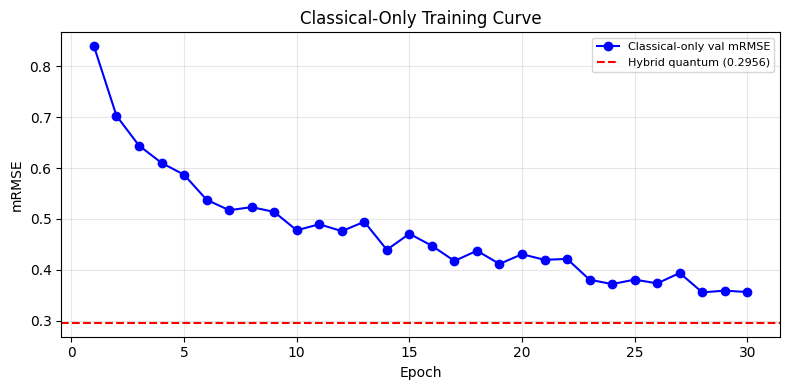

In [8]:
# Training curves
history = result.get("history", [])
if history:
    hdf = pd.DataFrame(history)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hdf["epoch"], hdf["val_rmse_mean"], "b-o", label="Classical-only val mRMSE")
    ax.axhline(holdout_quantum["rmse_mean"], color="red", linestyle="--",
               label=f"Hybrid quantum ({holdout_quantum['rmse_mean']:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mRMSE")
    ax.set_title("Classical-Only Training Curve")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
# Verdict
q_mrmse = holdout_quantum["rmse_mean"]
c_mrmse = holdout_classical["rmse_mean"]

n_q = sum(p.numel() for p in model_q.parameters())
n_c = sum(p.numel() for p in classical_model.parameters())

print("=== Test 6 Verdict ===")
print(f"Hybrid model params:        {n_q:,}")
print(f"Classical-only model params: {n_c:,}")
print(f"Hybrid holdout mRMSE:       {q_mrmse:.4f}")
print(f"Classical-only holdout mRMSE: {c_mrmse:.4f}")
print(f"Delta (Classical - Hybrid):  {c_mrmse - q_mrmse:+.4f}")

if c_mrmse > q_mrmse + 0.005:
    print("VERDICT: Hybrid model outperforms classical-only — quantum branch helps.")
elif abs(c_mrmse - q_mrmse) < 0.005:
    print("VERDICT: Models comparable — quantum branch doesn't provide clear advantage.")
else:
    print("VERDICT: Classical-only beats hybrid — quantum branch is counterproductive.")

=== Test 6 Verdict ===
Hybrid model params:        258,688
Classical-only model params: 189,259
Hybrid holdout mRMSE:       0.2956
Classical-only holdout mRMSE: 0.3616
Delta (Classical - Hybrid):  +0.0660
VERDICT: Hybrid model outperforms classical-only — quantum branch helps.
